# 06 · Uncertainty I — MC Dropout

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/06_mc_dropout.ipynb)

Cheapest UQ: train one surrogate with dropout, then sample at test time with dropout *on*. Spread across stochastic forward passes estimates predictive uncertainty.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.12.0+cu130


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate)
symlog = SymlogTransform(I0=1e-6)
biases = np.linspace(0.0, 0.6, 13)
profiles = [step(L) for L in np.geomspace(5e20, 5e22, 11)]
X, Y = build_sg_dataset(profiles, biases, scaling, sg, symlog); norm = Normalizer.fit(X)
net = IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR, hidden=128, n_layers=3, dropout=0.1, seed=0))
train_surrogate(net, X, Y, norm, epochs=2500, lr=2e-3)


[54.95186233520508,
 53.936912536621094,
 52.854923248291016,
 51.644283294677734,
 50.059635162353516,
 48.09608459472656,
 45.318721771240234,
 42.40941619873047,
 38.92779541015625,
 34.67653274536133,
 30.055591583251953,
 25.37796401977539,
 21.801549911499023,
 18.977109909057617,
 18.101749420166016,
 19.610523223876953,
 20.774580001831055,
 17.56297492980957,
 15.715839385986328,
 13.994404792785645,
 12.26674747467041,
 10.232603073120117,
 10.043680191040039,
 9.488561630249023,
 8.825627326965332,
 8.279544830322266,
 7.342861175537109,
 6.394597053527832,
 5.710805892944336,
 4.451164245605469,
 3.8726918697357178,
 3.1920225620269775,
 2.5036141872406006,
 2.2974183559417725,
 2.2068185806274414,
 2.2383840084075928,
 2.366257667541504,
 1.6229995489120483,
 1.4355891942977905,
 1.1623624563217163,
 1.0177230834960938,
 0.8754288554191589,
 1.1674824953079224,
 1.204221248626709,
 1.2599738836288452,
 1.1718050241470337,
 1.1105211973190308,
 0.8877735733985901,
 0.687593

## Test-time dropout sampling

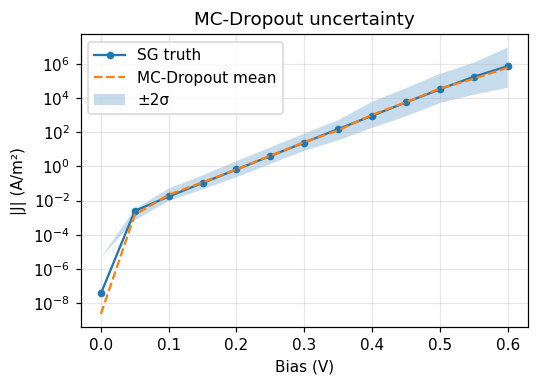

mean symlog σ = 0.325


In [3]:

def mc_predict(net, latent, biases, T=50):
    net.train()  # keep dropout active
    from bayespinn_inv.surrogate import make_features
    feats = np.stack([make_features(latent, b) for b in biases/VT])
    xb = norm(torch.tensor(feats, dtype=torch.float32))
    with torch.no_grad():
        S = np.stack([net(xb).numpy().ravel() for _ in range(T)])
    return S.mean(0), S.std(0)

C = step(1.7e21); lat = scaling.doping_to_net_input(C)
m_s, sd_s = mc_predict(net, lat, biases, T=100)
mean_I = symlog.inverse(m_s)
lo = symlog.inverse(m_s-2*sd_s); hi = symlog.inverse(m_s+2*sd_s)
Isg = sg_iv(C, biases)
plt.figure(figsize=(5,3.6))
plt.semilogy(biases, np.abs(Isg), "o-", label="SG truth", ms=4)
plt.semilogy(biases, np.abs(mean_I), "--", label="MC-Dropout mean")
plt.fill_between(biases, np.abs(lo), np.abs(hi), alpha=0.25, label="±2σ")
plt.xlabel("Bias (V)"); plt.ylabel("|J| (A/m²)"); plt.legend(); plt.grid(alpha=0.3)
plt.title("MC-Dropout uncertainty"); plt.tight_layout(); plt.show()
print(f"mean symlog σ = {sd_s.mean():.3f}")
